# Classifier analysis

In [27]:
import pandas as pd
import os
import numpy as np
from typing import Literal
from io import StringIO
import matplotlib.pyplot as plt

In [28]:
base_path = "../"
file_path = os.path.join(base_path, "gridsearch_classifiers.csv")

In [29]:
with open(file_path, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines[1:], start=1):
    # Fix classifier column
    first, mid = line.split("{", maxsplit=1)
    mid, last = mid.rsplit("}", maxsplit=1)
    mid = mid.replace(",", ";")
    lines[i] = first + "{" + mid + "}" + last

In [30]:
df = pd.read_csv(StringIO("".join(lines)))
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,CLASSIFIER,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,TruncateStrategy,TruncateStrategy,MaxStrategy,Tf4idfStrategy,"{""name"":""MLPClassifier"";""params"":{""bacterium_m...",TruncateStrategy,TruncateStrategy,0.927568,0.9275
1,TruncateStrategy,TruncateStrategy,MaxStrategy,TruncateStrategy,"{""name"":""BasicMLPClassifier"";""params"":{""mlp_pa...",TruncateStrategy,MaxStrategy,0.951452,0.9514
2,TruncateStrategy,TruncateStrategy,MaxStrategy,TfidfStrategy,"{""name"":""BasicMLPClassifier"";""params"":{""mlp_pa...",MaxStrategy,TruncateStrategy,0.949439,0.9494
3,TruncateStrategy,TruncateStrategy,MaxStrategy,MaxStrategy,"{""name"":""BasicMLPClassifier"";""params"":{""mlp_pa...",MaxStrategy,TruncateStrategy,0.951428,0.9514
4,TruncateStrategy,TruncateStrategy,MaxStrategy,TfidfStrategy,"{""name"":""BasicMLPClassifier"";""params"":{""mlp_pa...",MaxStrategy,MaxStrategy,0.949376,0.9493


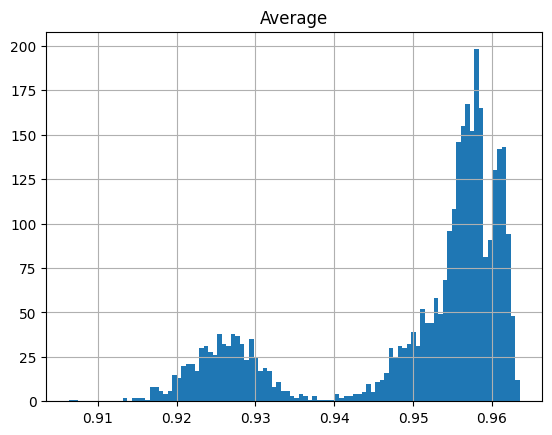

In [31]:
df.hist(column="Average", bins=100);

In [32]:
df.sort_values(axis=0, by="Average", ascending=False, inplace=True, ignore_index=True)
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,CLASSIFIER,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,TruncateStrategy,TfidfStrategy,Tf4idfStrategy,TfidfStrategy,"{""name"":""SklearnClassifier"";""params"":{""sklearn...",MaxStrategy,TruncateStrategy,0.963545,0.9635
1,TruncateStrategy,TfidfStrategy,MaxStrategy,TfidfStrategy,"{""name"":""SklearnClassifier"";""params"":{""sklearn...",MaxStrategy,MaxStrategy,0.963509,0.9635
2,TruncateStrategy,Tf4idfStrategy,TKPertStrategy,Tf4idfStrategy,"{""name"":""SklearnClassifier"";""params"":{""sklearn...",TruncateStrategy,MaxStrategy,0.963409,0.9634
3,MaxStrategy,Tf4idfStrategy,MaxStrategy,Tf4idfStrategy,"{""name"":""SklearnClassifier"";""params"":{""sklearn...",TruncateStrategy,TruncateStrategy,0.963373,0.9633
4,MaxStrategy,TfidfStrategy,MaxStrategy,TfidfStrategy,"{""name"":""SklearnClassifier"";""params"":{""sklearn...",MaxStrategy,TruncateStrategy,0.963382,0.9633


## Analysis by classifier

In [33]:
top_bottom_percentage = 0.15

DF_COLUMNS = ["NT2PHAGESTRAT", "MEGADNAPHAGESTRAT", "DNABERTPHAGESTRAT", "NT2BACTSTRAT", "MEGADNABACTSTRAT", "DNABERTBACTSTRAT"]
classifiers = df["CLASSIFIER"].unique()
strategies = np.unique(df[DF_COLUMNS].values)

def make_pretty(styler, title: str, cmap: str = "RdYlGn", vmin = None, vmax = None, percentage: bool = False, axis: Literal[0] | None = 0):
    styler.set_caption(title)
    if percentage:
        styler.format(lambda x: f"{x*100:.2f}%" if np.isfinite(x) else x) # type: ignore
    else:
        styler.format(precision=3)
    styler.background_gradient(axis=axis, cmap=cmap, vmin=vmin, vmax=vmax)
    return styler

### Average score

In [34]:
for classifier in classifiers:
    dfc = df[df["CLASSIFIER"] == classifier]
    weights_table = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

    model_name = classifier.split('"sklearn_model_name":"')[1].split('"')[0] if "sklearn_model_name" in classifier else classifier.split('"name":"')[1].split('"')[0]
    print(f"Classifier: {model_name}")
    print(dfc["Average"].describe())

    for column in DF_COLUMNS:
        for strat in strategies:
            weights_table.loc[strat, column] = dfc[dfc[column] == strat]["Average"].mean()


    display(weights_table.style.pipe(make_pretty, title=f"Average score per strategy - Classifier: {model_name}", cmap="YlGn"))


Classifier: LGBMClassifier
count    640.000000
mean       0.961117
std        0.000923
min        0.958100
25%        0.960500
50%        0.961200
75%        0.961700
max        0.963500
Name: Average, dtype: float64


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.961,0.961,0.961,0.961,0.961,0.961
TKPertStrategy,nan,0.961,nan,0.961,nan,nan
Tf4idfStrategy,0.961,0.961,nan,0.961,nan,nan
TfidfStrategy,0.961,0.961,nan,0.961,nan,nan
TruncateStrategy,0.961,0.961,0.961,nan,0.961,0.961


Classifier: RandomForestClassifier
count    640.000000
mean       0.958011
std        0.000971
min        0.955200
25%        0.957300
50%        0.958100
75%        0.958700
max        0.960700
Name: Average, dtype: float64


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.958,0.959,0.958,0.958,0.958,0.958
TKPertStrategy,nan,0.957,nan,0.958,nan,nan
Tf4idfStrategy,0.958,0.958,nan,0.958,nan,nan
TfidfStrategy,0.958,0.958,nan,0.958,nan,nan
TruncateStrategy,0.958,0.958,0.958,nan,0.958,0.958


Classifier: XGBClassifier
count    640.000000
mean       0.955847
std        0.001409
min        0.951300
25%        0.955000
50%        0.955800
75%        0.956800
max        0.959600
Name: Average, dtype: float64


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.956,0.956,0.956,0.955,0.956,0.956
TKPertStrategy,nan,0.956,nan,0.956,nan,nan
Tf4idfStrategy,0.956,0.956,nan,0.956,nan,nan
TfidfStrategy,0.956,0.956,nan,0.956,nan,nan
TruncateStrategy,0.956,0.956,0.956,nan,0.956,0.956


Classifier: BasicMLPClassifier
count    640.000000
mean       0.950184
std        0.004752
min        0.914400
25%        0.948200
50%        0.951000
75%        0.953100
max        0.959200
Name: Average, dtype: float64


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.951,0.950,0.950,0.952,0.949,0.951
TKPertStrategy,nan,0.949,nan,0.949,nan,nan
Tf4idfStrategy,0.950,0.951,nan,0.949,nan,nan
TfidfStrategy,0.950,0.951,nan,0.950,nan,nan
TruncateStrategy,0.950,0.949,0.950,nan,0.951,0.950


Classifier: MLPClassifier
count    640.000000
mean       0.925847
std        0.004351
min        0.906300
25%        0.923100
50%        0.926100
75%        0.928900
max        0.938600
Name: Average, dtype: float64


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.926,0.926,0.926,0.929,0.926,0.925
TKPertStrategy,nan,0.925,nan,0.925,nan,nan
Tf4idfStrategy,0.925,0.927,nan,0.925,nan,nan
TfidfStrategy,0.925,0.926,nan,0.925,nan,nan
TruncateStrategy,0.927,0.925,0.926,nan,0.926,0.926


### Best-worse composition

In [35]:
for classifier in classifiers:
    dfc = df[df["CLASSIFIER"] == classifier]
    n = len(dfc)
    df_best = dfc.iloc[:int(n*top_bottom_percentage)]
    df_worse = dfc.iloc[int(n*(1-top_bottom_percentage)):]

    table_best = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
    table_worse = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

    for column in DF_COLUMNS:
        table_best[column] = df_best[column].value_counts(normalize=True)
        table_worse[column] = df_worse[column].value_counts(normalize=True)
    
    model_name = classifier.split('"sklearn_model_name":"')[1].split('"')[0] if "sklearn_model_name" in classifier else classifier.split('"name":"')[1].split('"')[0]
    
    display(table_best.style.pipe(make_pretty, title=f"Best strategies {model_name} (top {top_bottom_percentage*100}%: {int(top_bottom_percentage*n)})", percentage=True))
    display(table_worse.style.pipe(make_pretty, title=f"Worse strategies {model_name} (bottom {top_bottom_percentage*100}%: {int(top_bottom_percentage*n)})", cmap="RdYlGn_r", percentage=True))

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,13.54%,22.92%,52.08%,23.96%,39.58%,43.75%
TKPertStrategy,nan,8.33%,nan,27.08%,nan,nan
Tf4idfStrategy,25.00%,28.12%,nan,25.00%,nan,nan
TfidfStrategy,37.50%,28.12%,nan,23.96%,nan,nan
TruncateStrategy,23.96%,12.50%,47.92%,nan,60.42%,56.25%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,43.75%,15.62%,48.96%,32.29%,56.25%,47.92%
TKPertStrategy,nan,30.21%,nan,18.75%,nan,nan
Tf4idfStrategy,14.58%,18.75%,nan,25.00%,nan,nan
TfidfStrategy,13.54%,17.71%,nan,23.96%,nan,nan
TruncateStrategy,28.12%,17.71%,51.04%,nan,43.75%,52.08%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,15.62%,27.08%,56.25%,23.96%,14.58%,26.04%
TKPertStrategy,nan,3.12%,nan,22.92%,nan,nan
Tf4idfStrategy,32.29%,27.08%,nan,22.92%,nan,nan
TfidfStrategy,36.46%,26.04%,nan,30.21%,nan,nan
TruncateStrategy,15.62%,16.67%,43.75%,nan,85.42%,73.96%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,32.29%,3.12%,53.12%,19.79%,73.96%,68.75%
TKPertStrategy,nan,57.29%,nan,19.79%,nan,nan
Tf4idfStrategy,16.67%,9.38%,nan,28.12%,nan,nan
TfidfStrategy,17.71%,5.21%,nan,32.29%,nan,nan
TruncateStrategy,33.33%,25.00%,46.88%,nan,26.04%,31.25%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,13.54%,21.88%,38.54%,12.50%,44.79%,65.62%
TKPertStrategy,nan,11.46%,nan,47.92%,nan,nan
Tf4idfStrategy,34.38%,18.75%,nan,22.92%,nan,nan
TfidfStrategy,33.33%,28.12%,nan,16.67%,nan,nan
TruncateStrategy,18.75%,19.79%,61.46%,nan,55.21%,34.38%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,33.33%,19.79%,59.38%,44.79%,67.71%,34.38%
TKPertStrategy,nan,21.88%,nan,10.42%,nan,nan
Tf4idfStrategy,17.71%,18.75%,nan,22.92%,nan,nan
TfidfStrategy,12.50%,15.62%,nan,21.88%,nan,nan
TruncateStrategy,36.46%,23.96%,40.62%,nan,32.29%,65.62%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,31.25%,20.83%,53.12%,60.42%,41.67%,69.79%
TKPertStrategy,nan,14.58%,nan,11.46%,nan,nan
Tf4idfStrategy,17.71%,23.96%,nan,11.46%,nan,nan
TfidfStrategy,25.00%,25.00%,nan,16.67%,nan,nan
TruncateStrategy,26.04%,15.62%,46.88%,nan,58.33%,30.21%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,20.83%,18.75%,53.12%,13.54%,59.38%,47.92%
TKPertStrategy,nan,28.12%,nan,30.21%,nan,nan
Tf4idfStrategy,29.17%,12.50%,nan,33.33%,nan,nan
TfidfStrategy,29.17%,15.62%,nan,22.92%,nan,nan
TruncateStrategy,20.83%,25.00%,46.88%,nan,40.62%,52.08%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,16.67%,25.00%,48.96%,60.42%,48.96%,41.67%
TKPertStrategy,nan,15.62%,nan,13.54%,nan,nan
Tf4idfStrategy,21.88%,19.79%,nan,13.54%,nan,nan
TfidfStrategy,25.00%,27.08%,nan,12.50%,nan,nan
TruncateStrategy,36.46%,12.50%,51.04%,nan,51.04%,58.33%


,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,28.12%,21.88%,59.38%,3.12%,46.88%,64.58%
TKPertStrategy,nan,19.79%,nan,33.33%,nan,nan
Tf4idfStrategy,25.00%,11.46%,nan,36.46%,nan,nan
TfidfStrategy,31.25%,17.71%,nan,27.08%,nan,nan
TruncateStrategy,15.62%,29.17%,40.62%,nan,53.12%,35.42%
